In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import csv


In [2]:
df = pd.read_csv('reviews.csv')

print(df.head())

                                    title  \
0  Cinépolis Cinemas - Oasis Mall Salalah   
1  Cinépolis Cinemas - Oasis Mall Salalah   
2  Cinépolis Cinemas - Oasis Mall Salalah   
3  Cinépolis Cinemas - Oasis Mall Salalah   
4  Cinépolis Cinemas - Oasis Mall Salalah   

                                                 url  stars  name  reviewUrl  \
0  https://www.google.com/maps/search/?api=1&quer...      5   NaN        NaN   
1  https://www.google.com/maps/search/?api=1&quer...      5   NaN        NaN   
2  https://www.google.com/maps/search/?api=1&quer...      5   NaN        NaN   
3  https://www.google.com/maps/search/?api=1&quer...      5   NaN        NaN   
4  https://www.google.com/maps/search/?api=1&quer...      5   NaN        NaN   

   text  
0   NaN  
1  Good  
2   NaN  
3   NaN  
4   NaN  


In [3]:
df = df.drop(columns=['url'])
print(df.head())


                                    title  stars  name  reviewUrl  text
0  Cinépolis Cinemas - Oasis Mall Salalah      5   NaN        NaN   NaN
1  Cinépolis Cinemas - Oasis Mall Salalah      5   NaN        NaN  Good
2  Cinépolis Cinemas - Oasis Mall Salalah      5   NaN        NaN   NaN
3  Cinépolis Cinemas - Oasis Mall Salalah      5   NaN        NaN   NaN
4  Cinépolis Cinemas - Oasis Mall Salalah      5   NaN        NaN   NaN


In [4]:
df['title'].unique()

array(['Cinépolis Cinemas - Oasis Mall Salalah',
       'Cinépolis Cinemas - Oman Avenues Mall سينما سينابولس - مسقط أفينيوز مول',
       'Cinepolis Cinemas'], dtype=object)

In [5]:
df = df.replace({'title': {'Cinépolis Cinemas - Oasis Mall Salalah': 'Oasis Mall Salalah', 'Cinépolis Cinemas - Oman Avenues Mall سينما سينابولس - مسقط أفينيوز مول': 'Oman Avenues Mall', 'Cinepolis Cinemas': 'Oasis Mall Sohar'}})

In [6]:
df = df.drop(columns=['name', 'reviewUrl'], errors='ignore')
print(df.head())

                title  stars  text
0  Oasis Mall Salalah      5   NaN
1  Oasis Mall Salalah      5  Good
2  Oasis Mall Salalah      5   NaN
3  Oasis Mall Salalah      5   NaN
4  Oasis Mall Salalah      5   NaN


In [7]:
!pip install wordcloud
!pip install deep_translator

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [8]:
from deep_translator import GoogleTranslator

def translate_review(df):
    df['review'] = df['text'].apply(lambda x: GoogleTranslator(source='auto', target='en').translate(x))
    return df

In [9]:
df = df.replace({'stars': {1: 'Negative', 2: 'Negative', 3: 'Neutral', 4: 'Positive', 5: 'Positive'}})

In [10]:
df.groupby('title')['stars'].value_counts()

title               stars   
Oasis Mall Salalah  Positive    625
                    Negative     65
                    Neutral      60
Oasis Mall Sohar    Positive    633
                    Negative     60
                    Neutral      57
Oman Avenues Mall   Positive    613
                    Negative     91
                    Neutral      46
Name: count, dtype: int64

In [11]:
df = df.rename(columns={'text': 'Review', 'stars': 'Rating', 'title': 'Location'})
df.head()

,Location,Rating,Review
0,Oasis Mall Salalah,Positive,NaN
1,Oasis Mall Salalah,Positive,Good
2,Oasis Mall Salalah,Positive,NaN
3,Oasis Mall Salalah,Positive,NaN
4,Oasis Mall Salalah,Positive,NaN


In [12]:
df_review = df.dropna()

In [13]:
df_review.head()

,Location,Rating,Review
1,Oasis Mall Salalah,Positive,Good
5,Oasis Mall Salalah,Positive,مكان ظخم اسعار منافسه
7,Oasis Mall Salalah,Positive,Good
10,Oasis Mall Salalah,Positive,"Great place to watch movie,"
11,Oasis Mall Salalah,Positive,🔥


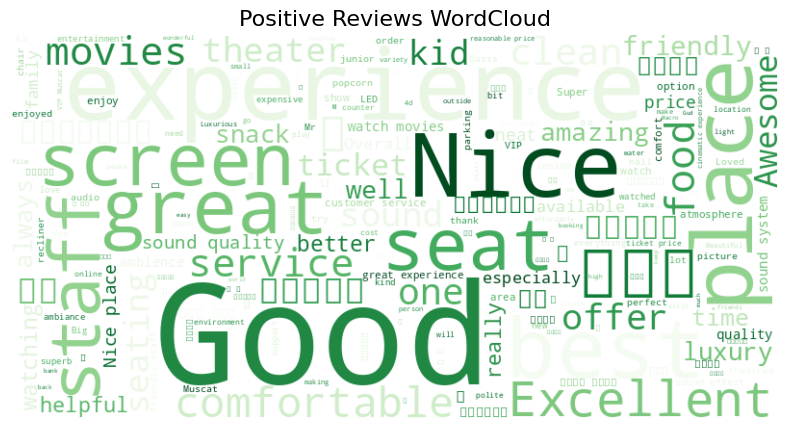

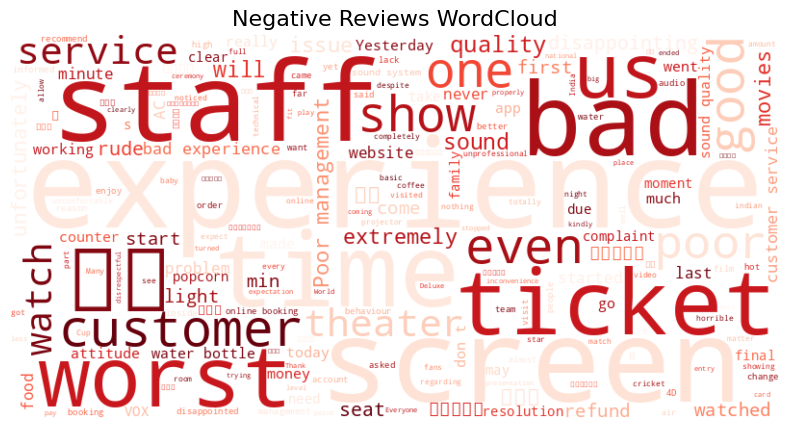

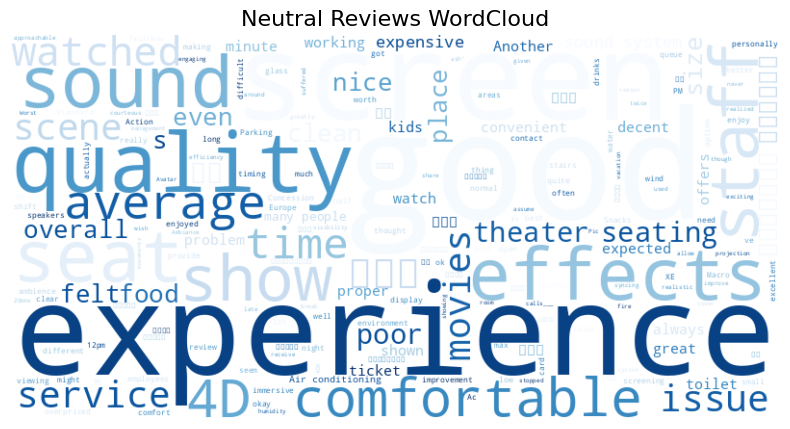

In [18]:
from wordcloud import WordCloud, STOPWORDS

# -----------------------------
# Custom stopwords
# -----------------------------
custom_stopwords = set(STOPWORDS)

custom_stopwords.update([
    'in', 'with', 'theatre', 'movie', 'cinepolis', 'cinema', 'cinemas', 'salalah', 'oman', 'avenues', 'mall', 'sohar', 'cinépolis'
])

# -----------------------------
# Split reviews by sentiment
# -----------------------------
positive_text = " ".join(
    df_review[df_review['Rating'] == 'Positive']['Review'].astype(str)
)

negative_text = " ".join(
    df_review[df_review['Rating'] == 'Negative']['Review'].astype(str)
)

neutral_text = " ".join(
    df_review[df_review['Rating'] == 'Neutral']['Review'].astype(str)
)

# -----------------------------
# Create WordCloud function
# -----------------------------
def generate_wordcloud(text, title, color):
    
    wc = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=custom_stopwords,
        colormap=color,
        max_words=200
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# -----------------------------
# Generate 3 Word Clouds
# -----------------------------
generate_wordcloud(positive_text, 'Positive Reviews WordCloud', 'Greens')

generate_wordcloud(negative_text, 'Negative Reviews WordCloud', 'Reds')

generate_wordcloud(neutral_text, 'Neutral Reviews WordCloud', 'Blues')

In [19]:
df_review.to_csv('cleaned_reviews.csv', index=False)

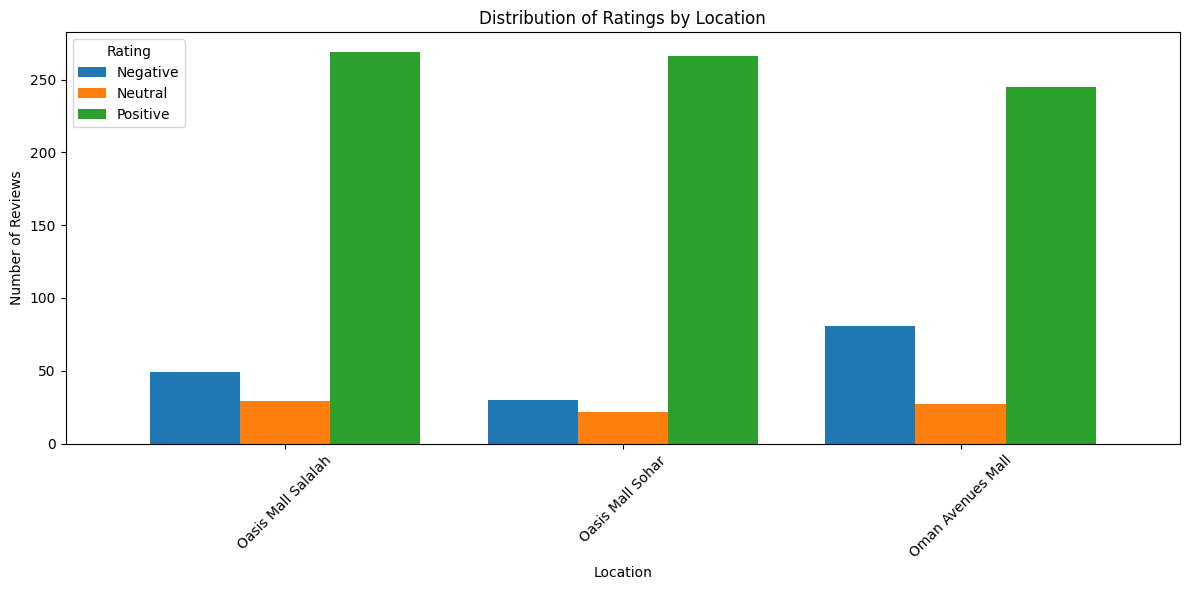

In [21]:

# Group ratings by location
rating_dist = (
    df_review.groupby('Location')['Rating']
    .value_counts()
    .unstack()
    .fillna(0)
)

# Plot
rating_dist.plot(
    kind='bar',
    figsize=(12, 6),
    width=0.8
)

plt.title('Distribution of Ratings by Location')
plt.xlabel('Location')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.legend(title='Rating')
plt.tight_layout()

plt.show()